In [ ]:
!pip install seaborn scikit-learn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc


In [ ]:
from google.colab import files
uploaded = files.upload()
df = pd.read_csv("processed.cleveland.data",header=None)

Saving processed.cleveland.data to processed.cleveland (1).data


In [ ]:
df.columns = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [ ]:
df['num'] = df['num'].apply(lambda x: 1 if x > 0 else 0)

In [ ]:
print("Dataset shape:", df.shape)

Dataset shape: (303, 14)


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        303 non-null    object 
 12  thal      303 non-null    object 
 13  num       303 non-null    int64  
dtypes: float64(11), int64(1), object(2)
memory usage: 33.3+ KB
None


In [ ]:
print(df.describe())

              age         sex          cp    trestbps        chol         fbs  \
count  303.000000  303.000000  303.000000  303.000000  303.000000  303.000000   
mean    54.438944    0.679868    3.158416  131.689769  246.693069    0.148515   
std      9.038662    0.467299    0.960126   17.599748   51.776918    0.356198   
min     29.000000    0.000000    1.000000   94.000000  126.000000    0.000000   
25%     48.000000    0.000000    3.000000  120.000000  211.000000    0.000000   
50%     56.000000    1.000000    3.000000  130.000000  241.000000    0.000000   
75%     61.000000    1.000000    4.000000  140.000000  275.000000    0.000000   
max     77.000000    1.000000    4.000000  200.000000  564.000000    1.000000   

          restecg     thalach       exang     oldpeak       slope         num  
count  303.000000  303.000000  303.000000  303.000000  303.000000  303.000000  
mean     0.990099  149.607261    0.326733    1.039604    1.600660    0.458746  
std      0.994971   22.875003 

In [ ]:
df = df.replace('?', np.nan)
df = df.apply(pd.to_numeric)
print(df.isnull().sum())
df = df.dropna()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
num         0
dtype: int64


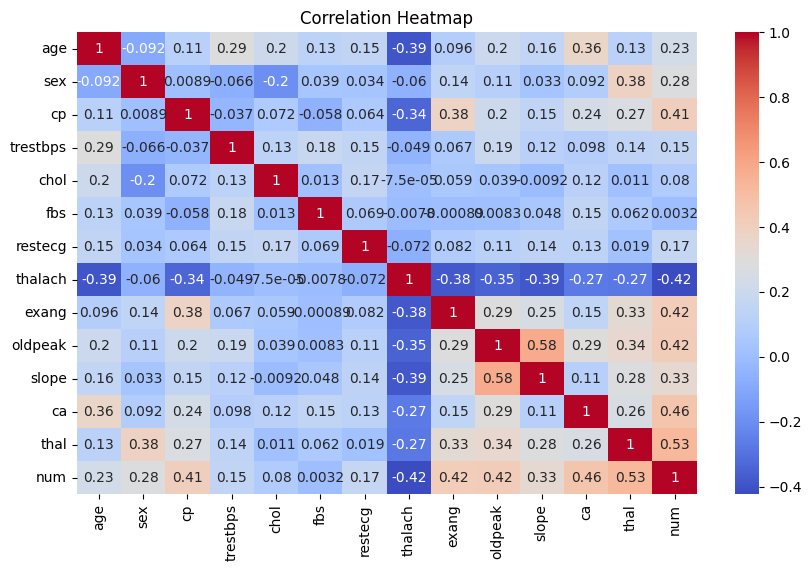

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

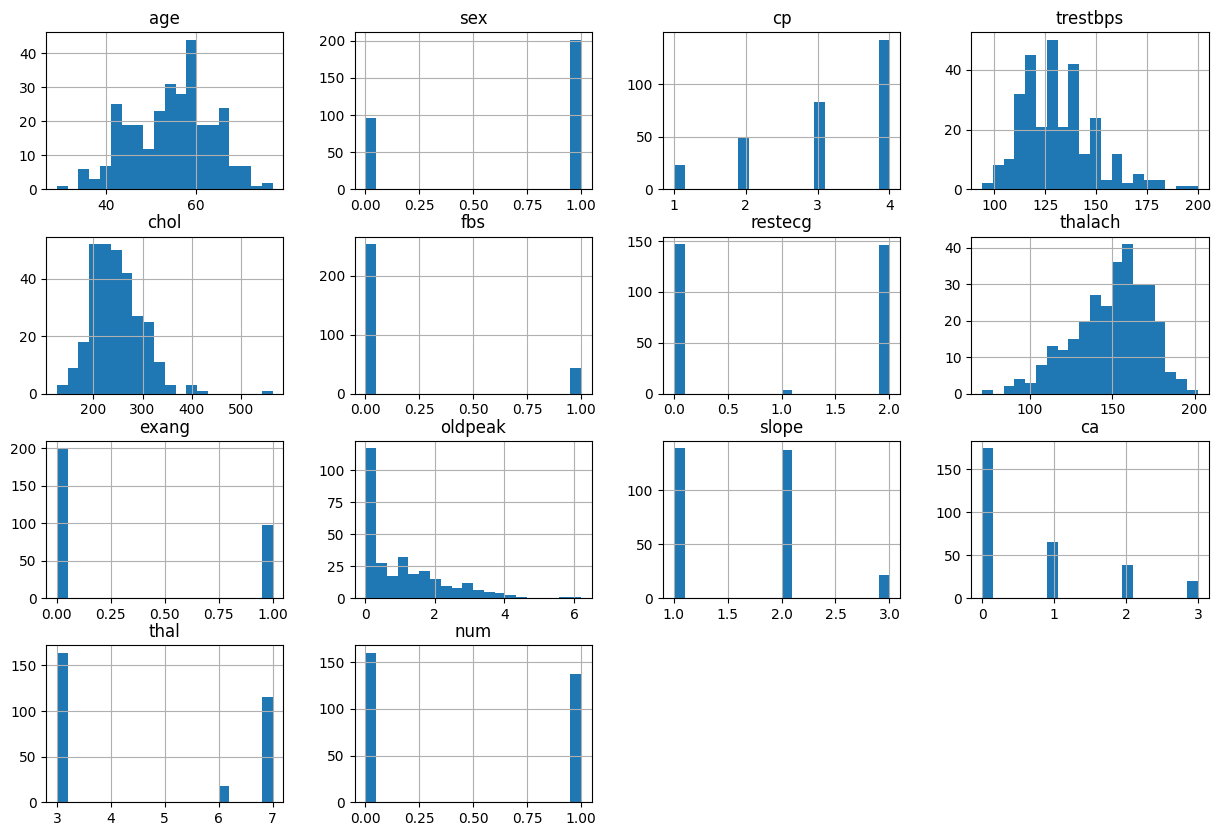

In [ ]:
df.hist(bins=20, figsize=(15, 10))
plt.show()

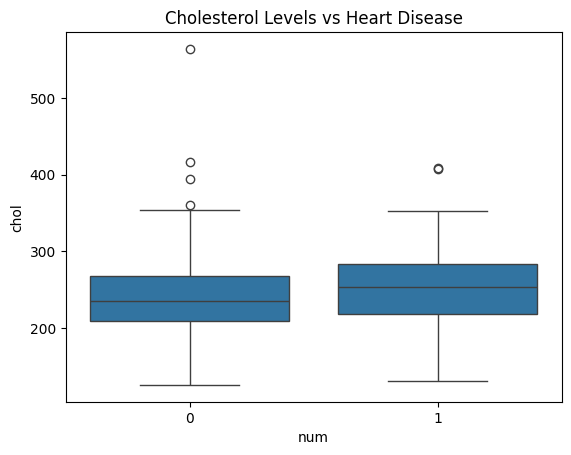

In [ ]:
sns.boxplot(x="num", y="chol", data=df)
plt.title("Cholesterol Levels vs Heart Disease")
plt.show()

In [ ]:
X = df.drop("num", axis=1)
Y = df["num"]
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=1)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
lr = LogisticRegression()
lr.fit(X_train, Y_train)
svm = SVC(probability=True)
svm.fit(X_train, Y_train)
rf = RandomForestClassifier(n_estimators=100, random_state=1)
rf.fit(X_train, Y_train)

RandomForestClassifier(random_state=1)

In [ ]:
models = [("Logistic Regression", lr),
          ("SVM", svm),
          ("Random Forest", rf)]

In [ ]:
for name, model in models:
    Y_pred = model.predict(X_test)
    print(f"--- {name} ---")
    print("Accuracy:", accuracy_score(Y_test, Y_pred))
    print("Classification Report:\n", classification_report(Y_test, Y_pred, zero_division=0))
    print("Confusion Matrix:\n", confusion_matrix(Y_test, Y_pred))
    print("\n")

--- Logistic Regression ---
Accuracy: 0.8
Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.77      0.79        30
           1       0.78      0.83      0.81        30

    accuracy                           0.80        60
   macro avg       0.80      0.80      0.80        60
weighted avg       0.80      0.80      0.80        60

Confusion Matrix:
 [[23  7]
 [ 5 25]]


--- SVM ---
Accuracy: 0.8666666666666667
Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.87      0.87        30
           1       0.87      0.87      0.87        30

    accuracy                           0.87        60
   macro avg       0.87      0.87      0.87        60
weighted avg       0.87      0.87      0.87        60

Confusion Matrix:
 [[26  4]
 [ 4 26]]


--- Random Forest ---
Accuracy: 0.8833333333333333
Classification Report:
               precision    recall  f1-score   support

     

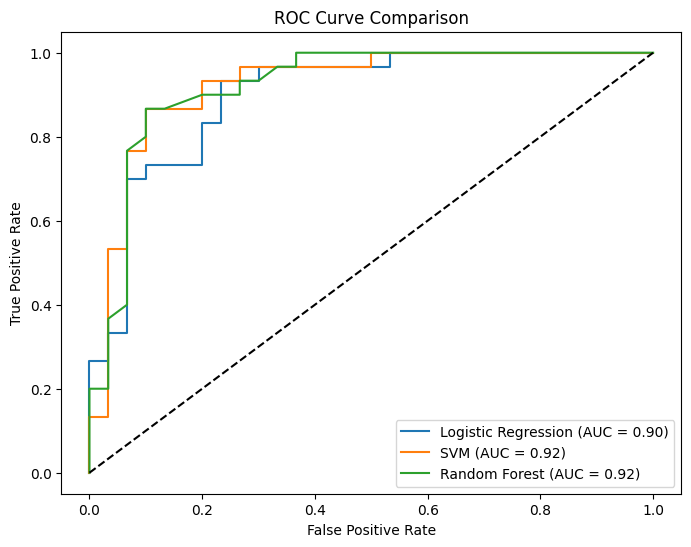

In [ ]:
plt.figure(figsize=(8,6))

for name, model in models:
    Y_probs = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(Y_test, Y_probs)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc(fpr,tpr):.2f})")

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [ ]:
columns = ["age", "sex", "cp", "trestbps", "chol", "fbs", "restecg","thalach", "exang", "oldpeak", "slope", "ca", "thal"]
new_patient = pd.DataFrame([[52, 1, 0, 125, 212, 0, 1, 168, 0, 1.0, 2, 2, 3]],columns=columns)
new_patient_scaled = scaler.transform(new_patient)
prediction = rf.predict(new_patient_scaled)
print("Prediction:", "Heart Disease" if prediction[0] == 1 else "No Heart Disease")

Prediction: No Heart Disease
